# Attention U-Net — learning-rate trial: 1e-4

Run this notebook for the lower-learning-rate experiment. The original `attention_unet.ipynb` and its saved results retain the previous run.

Start with a fresh kernel and run through **Validation threshold tuning and experiment saving**. Confirm the initial learning-rate message says `1.0e-04` before dataset loading begins. Reserve the optional final test cell for the configuration selected using validation results.

In [2]:
from pathlib import Path
from IPython import get_ipython
import copy, json, time
from dataclasses import asdict, dataclass
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

preprocessing_notebook = Path('shared/preprocessing.ipynb')
if not preprocessing_notebook.exists():
    preprocessing_notebook = Path('../shared/preprocessing.ipynb')
get_ipython().run_line_magic('run', str(preprocessing_notebook))

evaluation_notebook = Path('shared/evaluate.ipynb')
if not evaluation_notebook.exists():
    evaluation_notebook = Path('../shared/evaluate.ipynb')
get_ipython().run_line_magic('run', str(evaluation_notebook))

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'Project root: {PROJECT_ROOT}')
print(f'Dataset directory: {DEFAULT_DATA_DIR}')

Using device: cuda
Project root: d:\Projects\Wildfire-Spread-Prediction-from-Satellite-Imagery
Dataset directory: d:\Projects\Wildfire-Spread-Prediction-from-Satellite-Imagery\data


## Architecture

Attention gates filter encoder skip features before they are merged into the decoder. The model returns raw logits.

In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class AttentionGate(nn.Module):
    def __init__(self, gating_channels, skip_channels, inter_channels):
        super().__init__()
        self.gating_projection = nn.Sequential(
            nn.Conv2d(gating_channels, inter_channels, 1, bias=False),
            nn.BatchNorm2d(inter_channels),
        )
        self.skip_projection = nn.Sequential(
            nn.Conv2d(skip_channels, inter_channels, 1, bias=False),
            nn.BatchNorm2d(inter_channels),
        )
        self.psi = nn.Sequential(
            nn.ReLU(inplace=True), nn.Conv2d(inter_channels, 1, 1), nn.Sigmoid()
        )

    def forward(self, gating, skip):
        coefficients = self.psi(
            self.gating_projection(gating) + self.skip_projection(skip)
        )
        return skip * coefficients


class AttentionUpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels, dropout=0.0):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)
        self.attention = AttentionGate(
            out_channels, skip_channels, max(out_channels // 2, 1)
        )
        self.refine = ConvBlock(out_channels + skip_channels, out_channels, dropout)

    def forward(self, decoder, skip):
        decoder = self.up(decoder)
        if decoder.shape[-2:] != skip.shape[-2:]:
            decoder = F.interpolate(
                decoder, size=skip.shape[-2:], mode='bilinear', align_corners=False
            )
        attended_skip = self.attention(decoder, skip)
        return self.refine(torch.cat([decoder, attended_skip], dim=1))


class AttentionUNet(nn.Module):
    def __init__(self, in_channels=12, out_channels=1, base_channels=32, dropout=0.15):
        super().__init__()
        c = base_channels
        self.pool = nn.MaxPool2d(2)
        self.enc1 = ConvBlock(in_channels, c)
        self.enc2 = ConvBlock(c, c * 2)
        self.enc3 = ConvBlock(c * 2, c * 4)
        self.bottleneck = ConvBlock(c * 4, c * 8, dropout)
        self.up3 = AttentionUpBlock(c * 8, c * 4, c * 4, dropout)
        self.up2 = AttentionUpBlock(c * 4, c * 2, c * 2)
        self.up1 = AttentionUpBlock(c * 2, c, c)
        self.output = nn.Conv2d(c, out_channels, 1)
        self._initialize_weights()

    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        bottleneck = self.bottleneck(self.pool(e3))
        d3 = self.up3(bottleneck, e3)
        d2 = self.up2(d3, e2)
        d1 = self.up1(d2, e1)
        return self.output(d1)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Architecture smoke test (does not need the dataset).
_model = AttentionUNet(in_channels=NUM_CHANNELS)
_output = _model(torch.randn(2, NUM_CHANNELS, PATCH_SIZE, PATCH_SIZE))
assert _output.shape == (2, 1, PATCH_SIZE, PATCH_SIZE), _output.shape
print(f'Architecture OK: {tuple(_output.shape)}')
print(f'Trainable parameters: {count_params(_model):,}')
del _model, _output

Architecture OK: (2, 1, 64, 64)
Trainable parameters: 1,951,668


## Masked loss

The same weighted BCE + focal + Dice objective used by the CNN baseline. Uncertain (`-1`) target pixels are excluded.

In [4]:
def masked_weighted_bce(logits, targets, mask, pos_weight):
    per_pixel = F.binary_cross_entropy_with_logits(
        logits, targets.clamp(0, 1), pos_weight=pos_weight, reduction='none'
    )
    return (per_pixel * mask).sum() / mask.sum().clamp_min(1.0)


def masked_focal_loss(logits, targets, mask, gamma=2.0, alpha=0.75):
    targets = targets.clamp(0, 1)
    probabilities = torch.sigmoid(logits)
    pt = probabilities * targets + (1 - probabilities) * (1 - targets)
    alpha_t = alpha * targets + (1 - alpha) * (1 - targets)
    per_pixel = -alpha_t * (1 - pt).pow(gamma) * torch.log(pt.clamp_min(1e-6))
    return (per_pixel * mask).sum() / mask.sum().clamp_min(1.0)


def masked_dice_loss(logits, targets, mask, smooth=1.0):
    probabilities = torch.sigmoid(logits) * mask
    targets = targets.clamp(0, 1) * mask
    intersection = (probabilities * targets).sum(dim=(1, 2, 3))
    denominator = probabilities.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    return 1 - ((2 * intersection + smooth) / (denominator + smooth)).mean()


def combined_loss(logits, targets, mask, pos_weight, bce_weight=0.55,
                  focal_weight=0.25, dice_weight=0.20, focal_gamma=2.0):
    bce = masked_weighted_bce(logits, targets, mask, pos_weight)
    focal = masked_focal_loss(logits, targets, mask, gamma=focal_gamma)
    dice = masked_dice_loss(logits, targets, mask)
    total = bce_weight * bce + focal_weight * focal + dice_weight * dice
    return total, bce.item(), focal.item(), dice.item()


_logits = torch.tensor([[[[5.0, -5.0], [5.0, -5.0]]]])
_targets = torch.tensor([[[[1.0, 0.0], [1.0, -1.0]]]])
_mask = (_targets != UNCERTAIN_LABEL_VALUE).float()
_loss, _, _, _ = combined_loss(_logits, _targets, _mask, torch.tensor(1.0))
assert _loss.item() < 0.1, _loss.item()
print(f'Loss test OK: {_loss.item():.4f}')
del _logits, _targets, _mask, _loss

Loss test OK: 0.0045


## Training

The initial learning rate is **1e-4**, compared with **3e-4** in the previous F1-selected run. All other training settings are retained, including batch size 32, the combined loss, architecture, scheduler, and random seed.

The checkpoint is selected by validation F1 at a fixed threshold of 0.5. Early stopping uses the same score, with the earliest epoch retained on ties. The learning-rate scheduler still monitors validation loss. Threshold tuning happens afterward on the selected weights.

In [5]:
@dataclass
class TrainConfig:
    lr: float = 1e-4
    weight_decay: float = 1e-4
    batch_size: int = 32
    max_epochs: int = 30
    patience: int = 6
    checkpoint_threshold: float = 0.5
    grad_clip: float = 1.0
    bce_weight: float = 0.55
    focal_weight: float = 0.25
    dice_weight: float = 0.20
    focal_gamma: float = 2.0
    base_channels: int = 32
    dropout: float = 0.15


def train_model(config, train_loader, val_loader, pos_weight, verbose=True):
    model = AttentionUNet(
        NUM_CHANNELS, base_channels=config.base_channels, dropout=config.dropout
    ).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=config.lr, weight_decay=config.weight_decay
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2
    )
    positive_weight = torch.tensor(pos_weight, dtype=torch.float32, device=device)
    history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_iou': []}
    best_val_f1, best_state, stale_epochs = float('-inf'), None, 0
    checkpoint_selection = None

    for epoch in range(config.max_epochs):
        model.train()
        train_losses = []
        for inputs, targets, mask in train_loader:
            inputs, targets, mask = inputs.to(device), targets.to(device), mask.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss, _, _, _ = combined_loss(
                model(inputs), targets, mask, positive_weight, config.bce_weight,
                config.focal_weight, config.dice_weight, config.focal_gamma
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses, all_true, all_probability, all_mask = [], [], [], []
        with torch.no_grad():
            for inputs, targets, mask in val_loader:
                inputs, targets, mask = inputs.to(device), targets.to(device), mask.to(device)
                logits = model(inputs)
                loss, _, _, _ = combined_loss(
                    logits, targets, mask, positive_weight, config.bce_weight,
                    config.focal_weight, config.dice_weight, config.focal_gamma
                )
                val_losses.append(loss.item())
                all_true.append(targets.cpu().numpy())
                all_probability.append(torch.sigmoid(logits).cpu().numpy())
                all_mask.append(mask.cpu().numpy())

        metrics = compute_metrics(
            np.concatenate(all_true), np.concatenate(all_probability),
            np.concatenate(all_mask), threshold=config.checkpoint_threshold
        )
        train_loss, val_loss = float(np.mean(train_losses)), float(np.mean(val_losses))
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(metrics['f1'])
        history['val_iou'].append(metrics['iou'])
        # Keep the existing loss-based learning-rate schedule for this experiment.
        scheduler.step(val_loss)
        if verbose:
            print(f"Epoch {epoch+1:3d}/{config.max_epochs} | train_loss={train_loss:.4f} "
                  f"val_loss={val_loss:.4f} val_f1={metrics['f1']:.4f} "
                  f"val_iou={metrics['iou']:.4f} lr={optimizer.param_groups[0]['lr']:.2e}")
        if not np.isfinite(metrics['f1']) or not np.isfinite(val_loss):
            raise RuntimeError('Validation F1 or loss is not finite; checkpoint selection aborted.')
        # Strict improvement keeps the earliest checkpoint when F1 is tied.
        if metrics['f1'] > best_val_f1:
            best_val_f1 = metrics['f1']
            best_state = copy.deepcopy(model.state_dict())
            checkpoint_selection = {
                'metric': 'val_f1',
                'threshold': config.checkpoint_threshold,
                'epoch': epoch + 1,
                'val_f1': best_val_f1,
                'val_loss': val_loss,  # Loss at the selected epoch, not minimum loss.
            }
            stale_epochs = 0
            if verbose:
                print(f'  New best checkpoint: epoch {epoch + 1}, '
                      f'validation F1={best_val_f1:.4f} '
                      f'at threshold={config.checkpoint_threshold:.3f}')
        else:
            stale_epochs += 1
            if stale_epochs >= config.patience:
                if verbose:
                    print(f'Early stopping at epoch {epoch + 1}: '
                          f'validation F1 did not improve for {config.patience} epochs.')
                break

    if best_state is None:
        raise RuntimeError('Training did not produce a model state.')
    model.load_state_dict(best_state)
    return model, history, checkpoint_selection

In [6]:
FINAL_CONFIG = TrainConfig(lr=1e-4)
print(f'Learning-rate trial: initial lr={FINAL_CONFIG.lr:.1e} (previous run: 3e-4)')
train_loader, val_loader, test_loader, pos_weight = get_dataloaders(
    data_dir=DEFAULT_DATA_DIR, batch_size=FINAL_CONFIG.batch_size,
    augment_train=True, num_workers=0
)
inputs, targets, mask = next(iter(train_loader))
assert inputs.shape[1:] == (12, 64, 64)
assert targets.shape[1:] == (1, 64, 64) and mask.shape == targets.shape
assert torch.isfinite(inputs).all()
print(f'Data OK: {tuple(inputs.shape)}, pos_weight={pos_weight:.3f}')
del inputs, targets, mask

start_time = time.perf_counter()
model, history, checkpoint_selection = train_model(
    FINAL_CONFIG, train_loader, val_loader, pos_weight
)
training_time_sec = time.perf_counter() - start_time
print(f'Training time: {training_time_sec:.1f}s')
print(f"Selected epoch: {checkpoint_selection['epoch']} | "
      f"validation F1={checkpoint_selection['val_f1']:.4f} "
      f"at threshold={checkpoint_selection['threshold']:.3f} | "
      f"validation loss at selected epoch={checkpoint_selection['val_loss']:.4f}")

Learning-rate trial: initial lr=1.0e-04 (previous run: 3e-4)
Data OK: (32, 12, 64, 64), pos_weight=20.000
Epoch   1/30 | train_loss=0.3975 val_loss=0.3967 val_f1=0.2226 val_iou=0.1252 lr=1.00e-04
  New best checkpoint: epoch 1, validation F1=0.2226 at threshold=0.500
Epoch   2/30 | train_loss=0.3102 val_loss=0.3843 val_f1=0.2906 val_iou=0.1700 lr=1.00e-04
  New best checkpoint: epoch 2, validation F1=0.2906 at threshold=0.500
Epoch   3/30 | train_loss=0.2969 val_loss=0.3770 val_f1=0.2818 val_iou=0.1640 lr=1.00e-04
Epoch   4/30 | train_loss=0.2923 val_loss=0.3715 val_f1=0.2890 val_iou=0.1689 lr=1.00e-04
Epoch   5/30 | train_loss=0.2876 val_loss=0.3818 val_f1=0.3013 val_iou=0.1774 lr=1.00e-04
  New best checkpoint: epoch 5, validation F1=0.3013 at threshold=0.500
Epoch   6/30 | train_loss=0.2854 val_loss=0.3917 val_f1=0.3081 val_iou=0.1821 lr=1.00e-04
  New best checkpoint: epoch 6, validation F1=0.3081 at threshold=0.500
Epoch   7/30 | train_loss=0.2827 val_loss=0.4032 val_f1=0.3130 val

## Validation threshold tuning and experiment saving

Tune the prediction threshold using the F1-selected checkpoint restored by training. The fixed 0.5 checkpoint-selection threshold is separate from the tuned prediction threshold.

This cell saves validation scores and model weights for the learning-rate trial. Compare `checkpoint_selection.val_f1` with the previous run at the same 0.5 threshold. Stop here while choosing settings; the next cell is optional final test evaluation.

In [7]:
val_true, val_probability, val_mask = [], [], []
model.eval()
with torch.no_grad():
    for inputs, targets, mask in val_loader:
        logits = model(inputs.to(device))
        val_true.append(targets.numpy())
        val_probability.append(torch.sigmoid(logits).cpu().numpy())
        val_mask.append(mask.numpy())
val_true = np.concatenate(val_true)
val_probability = np.concatenate(val_probability)
val_mask = np.concatenate(val_mask)
threshold_results = []
for threshold in np.arange(0.10, 1.00, 0.025):
    metrics = compute_metrics(
        val_true, val_probability, val_mask, threshold=float(threshold)
    )
    threshold_results.append({'threshold': float(threshold), **metrics})
best_threshold_result = max(threshold_results, key=lambda item: item['f1'])
TUNED_THRESHOLD = best_threshold_result['threshold']
print(f"Best threshold={TUNED_THRESHOLD:.3f}, F1={best_threshold_result['f1']:.4f}, "
      f"precision={best_threshold_result['precision']:.4f}, "
      f"recall={best_threshold_result['recall']:.4f}, IoU={best_threshold_result['iou']:.4f}")

# Save the experiment before using the test set.
num_params = count_params(model)
validation_results = {
    'model_name': 'attention_unet',
    'split': 'validation',
    'threshold': TUNED_THRESHOLD,
    'metrics': {key: value for key, value in best_threshold_result.items()
                if key != 'threshold'},
    'config': asdict(FINAL_CONFIG),
    'seed': SEED,
    'checkpoint_selection': checkpoint_selection,
    'training_time_sec': training_time_sec,
    'num_params': num_params,
}
VALIDATION_PATH = PROJECT_ROOT / 'results' / 'attention_unet_validation_f1_lr_1e-4.json'
save_results(validation_results, str(VALIDATION_PATH))

CHECKPOINT_PATH = PROJECT_ROOT / 'checkpoints' / 'attention_unet_best_f1_lr_1e-4.pt'
CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save({
    'model_state_dict': model.state_dict(),
    'config': asdict(FINAL_CONFIG),
    'seed': SEED,
    'num_params': num_params,
    'checkpoint_selection': checkpoint_selection,
    'threshold': TUNED_THRESHOLD,
    'training_history': history,
    'validation_metrics': validation_results['metrics'],
}, CHECKPOINT_PATH)
print(f'Checkpoint saved to {CHECKPOINT_PATH}')
print('Trial saved. Compare validation results before running final test evaluation.')

Best threshold=0.725, F1=0.3497, precision=0.2787, recall=0.4692, IoU=0.2119
Saved results to d:\Projects\Wildfire-Spread-Prediction-from-Satellite-Imagery\results\attention_unet_validation_f1_lr_1e-4.json
Checkpoint saved to d:\Projects\Wildfire-Spread-Prediction-from-Satellite-Imagery\checkpoints\attention_unet_best_f1_lr_1e-4.pt
Trial saved. Compare validation results before running final test evaluation.


## Optional final test evaluation

Run this cell only after choosing the configuration using validation results. The previous cell already saved validation scores and model weights.

Test metrics are written to `results/attention_unet_metrics_f1_lr_1e-4_tuned_threshold.json`. This experiment uses separate output filenames from earlier runs.

{
  "accuracy": 0.9768940316741281,
  "precision": 0.2886244345505234,
  "recall": 0.5757669184522892,
  "f1": 0.3845026924295217,
  "iou": 0.2380088723315605,
  "roc_auc": 0.9399427015608404
}
Threshold: 0.725; params: 1,951,668
Saved results to d:\Projects\Wildfire-Spread-Prediction-from-Satellite-Imagery\results\attention_unet_metrics_f1_lr_1e-4_tuned_threshold.json


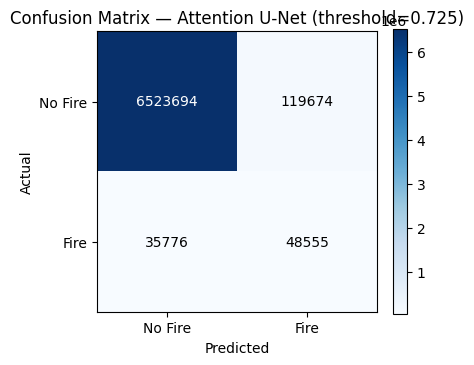

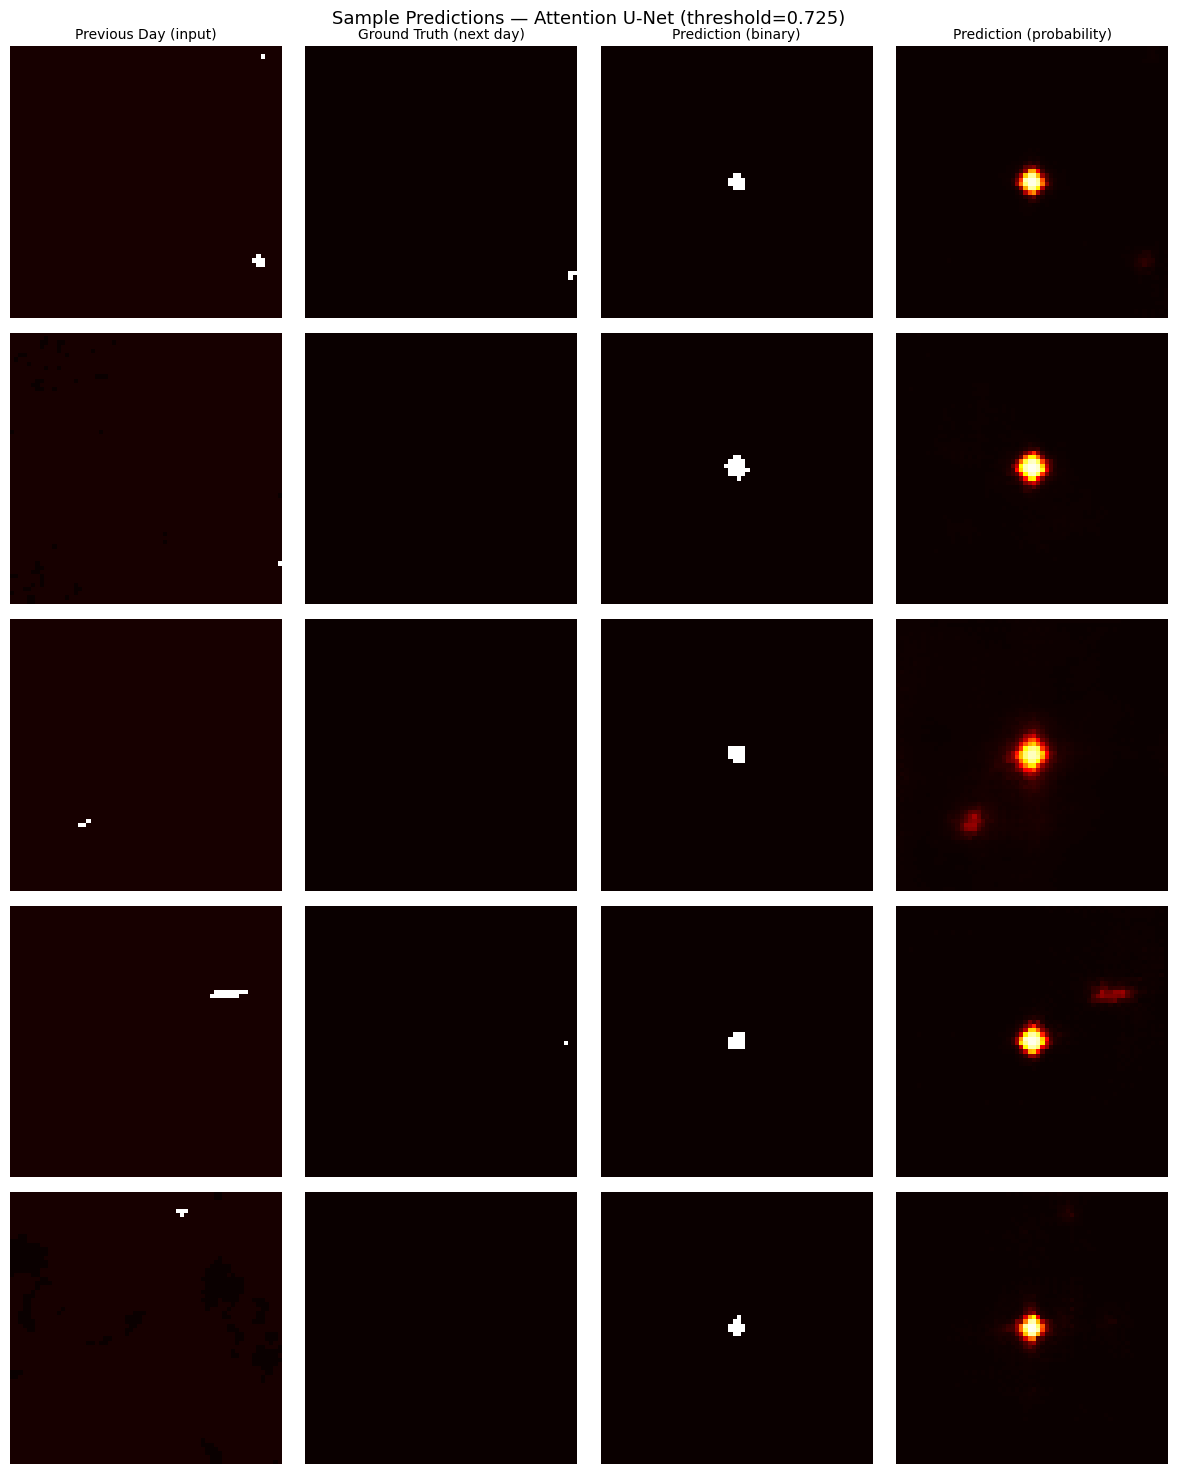

In [8]:
num_params = count_params(model)
results = evaluate_model(
    model, test_loader, device, model_name='attention_unet',
    threshold=TUNED_THRESHOLD, training_time_sec=training_time_sec,
    num_params=num_params
)
results['checkpoint_selection'] = checkpoint_selection
results['config'] = asdict(FINAL_CONFIG)
results['seed'] = SEED
results['split'] = 'test'
print(json.dumps(
    {k: v for k, v in results['metrics'].items() if k != 'confusion_matrix'}, indent=2
))
print(f'Threshold: {TUNED_THRESHOLD:.3f}; params: {num_params:,}')

RESULTS_PATH = PROJECT_ROOT / 'results' / 'attention_unet_metrics_f1_lr_1e-4_tuned_threshold.json'
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
save_results(results, str(RESULTS_PATH))
plot_confusion_matrix(
    results['metrics']['confusion_matrix'],
    model_name=f'Attention U-Net (threshold={TUNED_THRESHOLD:.3f})'
)
plot_prediction_grid(
    model, test_loader, device,
    model_name=f'Attention U-Net (threshold={TUNED_THRESHOLD:.3f})',
    n_samples=5, threshold=TUNED_THRESHOLD
)